# radSeq — generating temporal radar sequences with a diffusion transformer

**Status report.** This notebook starts from zero: what the project is trying to
do, how the model works, what was built, what was measured, and what the
measurements turned out to mean.

It is written for a radar audience. Range–Doppler maps, Doppler bins, clutter,
SCNR, Swerling models and CFAR are used directly. The generative machinery —
diffusion models, transformers, attention — is developed from first principles,
equations included.

The story runs in the order it happened:

1. The problem, and why sequences rather than single frames
2. The simulator — what we are learning to imitate
3. Diffusion models, formally
4. The architecture, and the one design choice everything hinges on
5. Training
6. The first results, which looked good
7. Problem 1 — the intensity distribution is wrong
8. Problem 2 — the metrics were scoring the wrong thing
9. Root cause
10. Where this leaves the project

---

In [1]:
import os, sys, json, re, math
sys.path.insert(0, os.path.abspath(".."))
os.chdir(os.path.abspath(".."))          # run from the repo root

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import gridspec

torch.manual_seed(0)
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})
RED, BLUE, GREY = "#c0392b", "#2c6fbb", "#7f8c8d"
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEV)

torch 2.12.1+cu130 | device: cuda


---
## 1. The problem

Machine-learning models for radar — detectors, classifiers, trackers — need
large volumes of *labelled* data. For radar that is a bottleneck: real
collections are expensive, and ground truth (which target, at what range and
velocity, of what type) usually has to come from an instrumented trial.

A physics simulator solves the labelling problem, because we know exactly what
we put in. But a simulator only produces what its author modelled. Its clutter,
its target fluctuation statistics and its noise are whatever the equations say
they are, and a network trained on that inherits every one of those assumptions.

The idea here is to sit a **generative model** on top of the simulator. Train it
on simulated data, and it learns the *distribution*, not the recipe — after
which it can be sampled cheaply and, in principle, steered ("give me a Swerling-1
target closing at 5 m/s in heavy clutter").

### Why sequences and not single frames

A single RD map tells you where the energy is. It does not tell you how the
energy is *moving*, and motion is what a tracker consumes. Range and Doppler are
also not independent across time: a target's range walk over the coherent
processing intervals is the integral of the very radial velocity that puts it in
its Doppler bin. A per-frame generator has no way to respect that coupling.

So the object of study is a **sequence**: $L = 16$ consecutive $64 \times 64$ RD
maps, $T_f = 0.5$ s apart. The model must produce frames that are individually
plausible *and* consistent with each other over time.

---
## 2. The simulator — what we are learning to imitate

The training data comes from a temporal extension of a single-frame RD
simulator. Each sequence contains:

| Component | Model |
|---|---|
| Targets | 1–5, constant-acceleration kinematics $r(t) = r_0 + v_0 t + \tfrac{1}{2} a t^2$ |
| Target classes | steady point / Swerling-1 (per-frame $\mathrm{Exp}$ power) / range-extended (3 scatterers, flanks $-3$ dB) |
| Clutter | AR(1) correlated across frames, $z_\ell = \rho\, z_{\ell-1} + \sqrt{1-\rho^2}\, \epsilon_\ell$ |
| Output | $20 \log_{10}(|\mathrm{RD}| + 10^{-6})$, i.e. log-magnitude in dB |

Every sequence carries its ground truth: continuous $(\text{range bin},
\text{Doppler bin})$ per target per frame, plus $v_0$, acceleration, class and
the environment parameters $[\mathrm{CNR}, \mathrm{SCNR}, \rho]$.

The cache is **20 000 training** and **2 000 validation** sequences (~5.5 GB),
normalised by the training-split mean and standard deviation.

sequence: (16, 64, 64)  (frames, range bins, Doppler bins)
targets : 1   v0 = [2.219566583633423]  m/s
classes : [1]   (0 steady, 1 Swerling-1, 2 extended)
env     : CNR 15.0 dB, SCNR 2.2 dB, rho 0.21


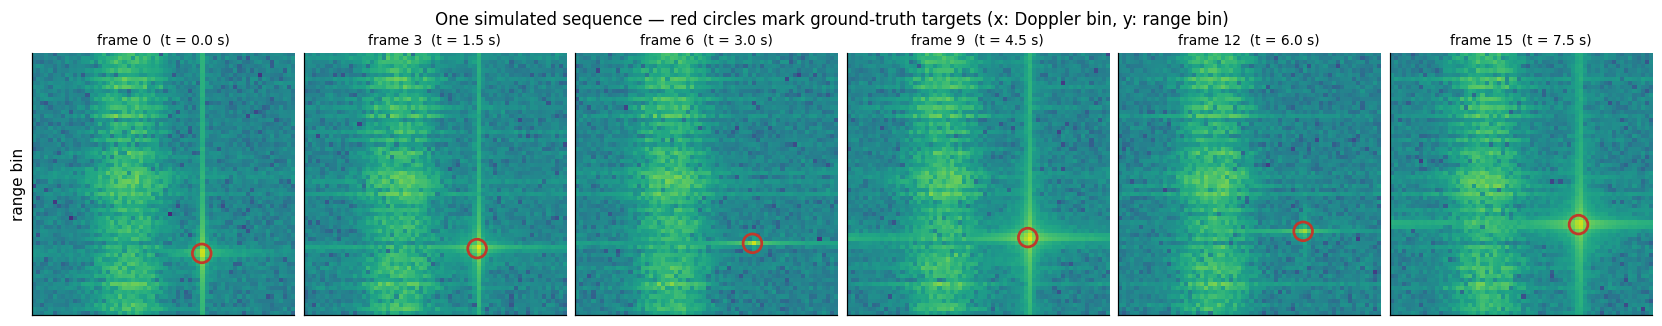

In [2]:
from src.simulator import TemporalRadarSimulator

sim = TemporalRadarSimulator(seq_len=16, frame_interval=0.5)
torch.manual_seed(7)
seq = sim.gen_sequence()
x, traj, m = seq["x"], seq["traj"], seq["n_targets"]
print(f"sequence: {tuple(x.shape)}  (frames, range bins, Doppler bins)")
print(f"targets : {m}   v0 = {seq['v0'].tolist()}  m/s")
print(f"classes : {seq['cls'].tolist()}   (0 steady, 1 Swerling-1, 2 extended)")
print(f"env     : CNR {seq['env'][0]:.1f} dB, SCNR {seq['env'][1]:.1f} dB, rho {seq['env'][2]:.2f}")

show = [0, 3, 6, 9, 12, 15]
fig, axes = plt.subplots(1, len(show), figsize=(15, 2.9), constrained_layout=True)
vmin, vmax = float(x.min()), float(x.max())
for ax, l in zip(axes, show):
    ax.imshow(x[l], origin="lower", cmap="viridis", vmin=vmin, vmax=vmax, aspect="equal")
    ax.scatter(traj[:m, l, 1], traj[:m, l, 0], s=150, facecolors="none",
               edgecolors=RED, linewidths=1.8)
    ax.set_title(f"frame {l}  (t = {l*0.5:.1f} s)", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
axes[0].set_ylabel("range bin")
fig.suptitle("One simulated sequence — red circles mark ground-truth targets "
             "(x: Doppler bin, y: range bin)", fontsize=11)
plt.show()

The targets drift smoothly across frames while the clutter background decorrelates
slowly. That joint behaviour — coherent target motion on a temporally correlated
background — is exactly what the generative model has to reproduce.

---
## 3. Diffusion models, formally

A diffusion model turns generation into a sequence of denoising problems.

### Forward process

Take a clean sequence $\mathbf{x}_0$ and corrupt it over $T = 1000$ steps with a
Markov chain that adds Gaussian noise on a fixed variance schedule $\beta_t$:

$$q(\mathbf{x}_t \mid \mathbf{x}_{t-1}) = \mathcal{N}\!\left(\mathbf{x}_t;\ \sqrt{1-\beta_t}\,\mathbf{x}_{t-1},\ \beta_t \mathbf{I}\right)$$

Because Gaussians compose, this has a closed form that jumps straight to any $t$.
With $\alpha_t = 1 - \beta_t$ and $\bar\alpha_t = \prod_{s=1}^{t} \alpha_s$:

$$q(\mathbf{x}_t \mid \mathbf{x}_0) = \mathcal{N}\!\left(\mathbf{x}_t;\ \sqrt{\bar\alpha_t}\,\mathbf{x}_0,\ (1-\bar\alpha_t)\mathbf{I}\right)
\qquad\Longleftrightarrow\qquad
\mathbf{x}_t = \sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol{\epsilon},\quad \boldsymbol{\epsilon}\sim\mathcal{N}(0,\mathbf{I})$$

$\bar\alpha_t$ decreases from $\approx 1$ to $\approx 0$, so $\mathbf{x}_T$ is
indistinguishable from white noise. We use the **cosine** schedule, which spends
less of its budget at the fully-destroyed end than the original linear one.

### Reverse process and the training objective

Generation reverses the chain. The reverse transition is also Gaussian for small
$\beta_t$, and its mean can be written in terms of the noise that was added.
So instead of predicting a mean, the network $\boldsymbol{\epsilon}_\theta$ is
trained to predict **the noise itself** ($\epsilon$-parameterisation):

$$\mathcal{L}_{\text{DiT}} = \mathbb{E}_{\mathbf{x}_0,\,t\sim\mathcal{U}[1,T],\,\boldsymbol{\epsilon}}
\left[\left\lVert \boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta\!\left(\sqrt{\bar\alpha_t}\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\boldsymbol{\epsilon},\ t\right) \right\rVert^2\right]$$

That is the entire training signal: corrupt a real sequence by a random amount,
ask the network which noise was added, penalise the squared error.

Given a prediction $\hat{\boldsymbol{\epsilon}}$ we can always recover an estimate
of the clean sequence by inverting the forward equation:

$$\hat{\mathbf{x}}_0 = \frac{\mathbf{x}_t - \sqrt{1-\bar\alpha_t}\,\hat{\boldsymbol{\epsilon}}}{\sqrt{\bar\alpha_t}}$$

This quantity matters later — it is how we ask "what does the model *think* the
clean data looks like?"

### Sampling

We sample with **DDIM**, a deterministic reverse process that reaches good
samples in ~50 steps instead of 1000:

$$\mathbf{x}_{t-1} = \sqrt{\bar\alpha_{t-1}}\,\hat{\mathbf{x}}_0 + \sqrt{1-\bar\alpha_{t-1}}\,\hat{\boldsymbol{\epsilon}}$$

Start from $\mathbf{x}_T \sim \mathcal{N}(0,\mathbf{I})$, iterate, and the final
$\hat{\mathbf{x}}_0$ is a generated sequence.

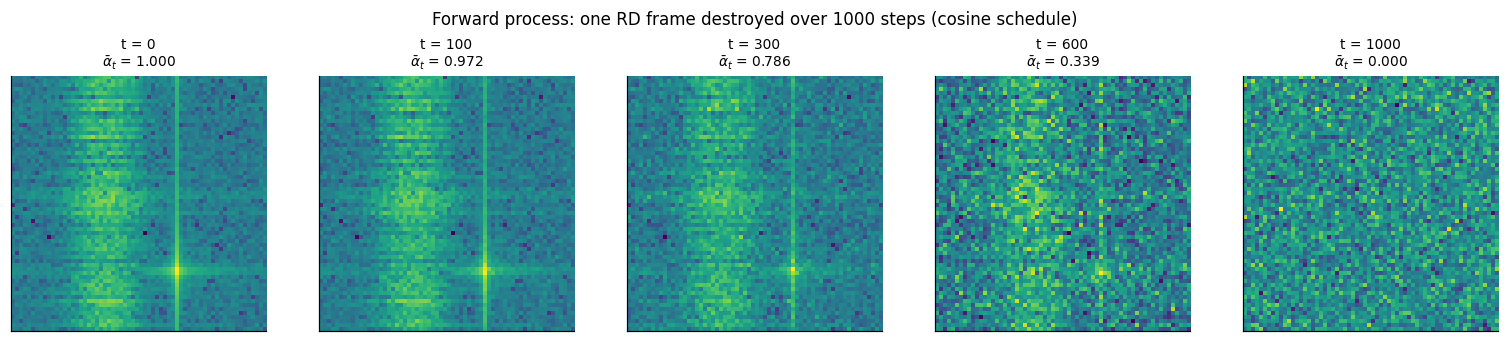

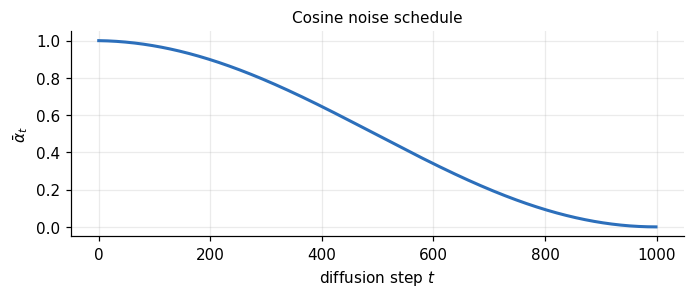

In [3]:
from src.diffusion import GaussianDiffusion
from src.dataset import RadarSequenceDataset

diff = GaussianDiffusion(1000)
stats = torch.load("data/cache/stats.pt")
x0 = ((x - stats["mean"]) / stats["std"])[None]     # normalised, (1, L, 64, 64)

ts = [0, 100, 300, 600, 1000]
fig, axes = plt.subplots(1, len(ts), figsize=(14, 3.0), constrained_layout=True)
for ax, tv in zip(axes, ts):
    if tv == 0:
        xt = x0
    else:
        t = torch.tensor([min(tv, 999)])
        xt = diff.q_sample(x0, t, torch.randn_like(x0))
    ax.imshow(xt[0, 0], origin="lower", cmap="viridis", aspect="equal")
    ab = float(diff.alphas_bar[min(tv, 999)])
    ax.set_title(f"t = {tv}\n" + r"$\bar\alpha_t$ = " + f"{ab:.3f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("Forward process: one RD frame destroyed over 1000 steps "
             "(cosine schedule)", fontsize=11)
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 2.6), constrained_layout=True)
ax.plot(diff.alphas_bar.numpy(), color=BLUE, lw=2)
ax.set_xlabel("diffusion step $t$"); ax.set_ylabel(r"$\bar\alpha_t$")
ax.set_title("Cosine noise schedule", fontsize=10)
plt.show()

---
## 4. The architecture — and the one choice everything hinges on

The denoiser $\boldsymbol{\epsilon}_\theta$ is a **Diffusion Transformer (DiT)**.
Transformers operate on sets of vectors ("tokens"), so an RD sequence must first
be cut into tokens.

### Patches as tokens

Each frame is divided into $p \times p = 8 \times 8$ patches taken with stride
$s = 4$, so **patches overlap by half**. That gives $15 \times 15 = 225$ patch
sites per frame, each flattened and linearly projected to a $d = 256$ dimensional
token. A sequence therefore becomes a $(L, P, d) = (16, 225, 256)$ tensor.

The overlap is deliberate and comes from the proposal: a target moving across a
patch boundary stays visible inside at least one patch at all times, instead of
being split between two.

### Attention: the critical design decision

A standard video transformer would attend both across space and across time. The
proposal specifies something narrower — **attention over time only**. Concretely,
the token tensor is reshaped so that the patch index joins the batch dimension:

$$(B,\, L,\, P,\, d) \;\longrightarrow\; (B \cdot P,\ L,\ d)$$

and self-attention runs over the length-$L$ axis. Each of the 225 spatial sites
therefore gets **its own independent temporal transformer**. Site $(i,j)$ sees
its own history across all 16 frames and nothing else — two patches in the same
frame never exchange information at any depth.

The motivation is cost and inductive bias: motion is a temporal phenomenon, and
attention over 16 frames is far cheaper than attention over $225 \times 16$
tokens. *Remember this choice — sections 7–9 come back to it.*

### Conditioning on $t$

The network must know how noisy its input is. The timestep is embedded
sinusoidally and fed through an MLP to a vector $\mathbf{c}$, which modulates
every block via **adaLN-Zero**: the block predicts per-channel scale, shift and
gate parameters from $\mathbf{c}$,

$$\mathbf{h} = \mathrm{LayerNorm}(\mathbf{z}) \odot (1 + \boldsymbol{\gamma}(\mathbf{c})) + \boldsymbol{\beta}(\mathbf{c}), \qquad
\mathbf{z} \leftarrow \mathbf{z} + \mathbf{g}(\mathbf{c}) \odot \mathrm{Attn}(\mathbf{h})$$

with the gate $\mathbf{g}$ initialised to zero so each block starts as an identity
map and training begins stably.

**Size:** 8 blocks, $d = 256$, 8 heads — 9.83 M parameters.

patch grid: 15 x 15 = 225 sites per frame, token dim 256


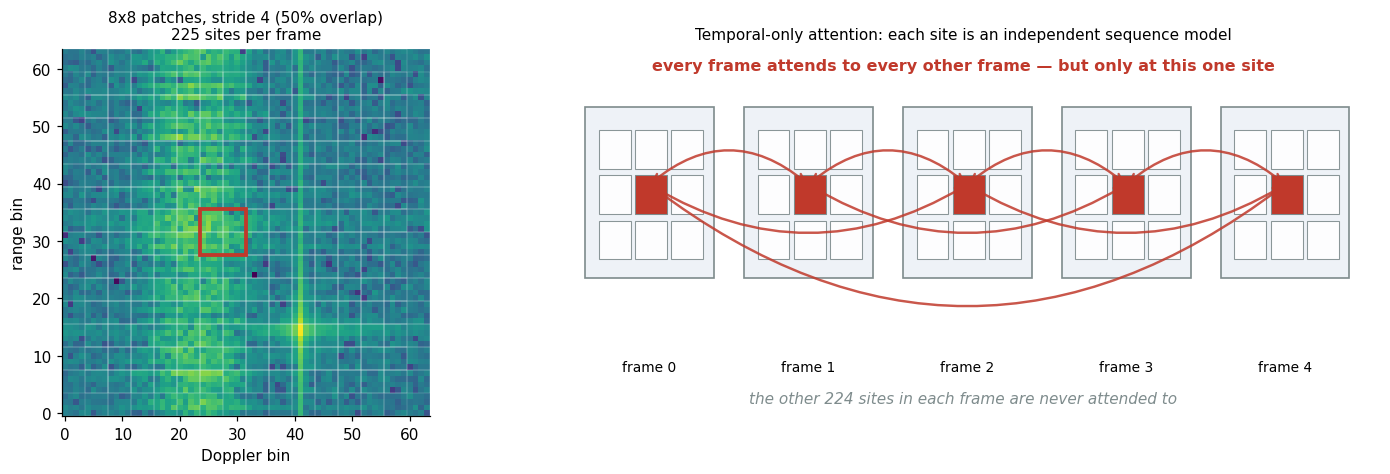

In [4]:
from src.patching import num_patches

pr, pc = num_patches(64, 64, 8, 4)
print(f"patch grid: {pr} x {pc} = {pr*pc} sites per frame, token dim 256")

fig = plt.figure(figsize=(13, 4.2), constrained_layout=True)
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.45], figure=fig)

# ---- left: the overlapping patch grid on a real frame
ax = fig.add_subplot(gs[0])
ax.imshow(x[0], origin="lower", cmap="viridis", aspect="equal")
for i in range(0, 57, 4):
    for j in range(0, 57, 4):
        ax.add_patch(plt.Rectangle((j - .5, i - .5), 8, 8, fill=False,
                                   edgecolor="white", lw=0.25, alpha=0.45))
ax.add_patch(plt.Rectangle((23.5, 27.5), 8, 8, fill=False, edgecolor=RED, lw=2.5))
ax.set_title("8x8 patches, stride 4 (50% overlap)\n225 sites per frame", fontsize=10)
ax.set_xlabel("Doppler bin"); ax.set_ylabel("range bin"); ax.grid(False)

# ---- right: what one site attends to
ax = fig.add_subplot(gs[1]); ax.axis("off")
ax.set_xlim(-0.5, 10.5); ax.set_ylim(-2.6, 4.3)
for k in range(5):
    xo = k * 2.1
    ax.add_patch(plt.Rectangle((xo, 0), 1.7, 3.2, fill=True, facecolor="#eef2f7",
                               edgecolor=GREY, lw=1.1))
    for r in range(3):
        for c in range(3):
            hit = (r == 1 and c == 1)
            ax.add_patch(plt.Rectangle((xo + .18 + c * .48, .35 + r * .85), .42, .72,
                                       facecolor=RED if hit else "white",
                                       edgecolor=GREY, lw=.7, alpha=1 if hit else .9))
    ax.text(xo + .85, -1.75, f"frame {k}", ha="center", fontsize=9)
from matplotlib.patches import FancyArrowPatch
# attention is all-to-all over the 16 frames, not neighbour-to-neighbour
for a, b, rad in [(0, 1, -.42), (1, 2, -.42), (2, 3, -.42), (3, 4, -.42),
                  (0, 2, .30), (2, 4, .30), (1, 3, .30), (0, 4, .38)]:
    ax.add_patch(FancyArrowPatch((a * 2.1 + .85, 1.75), (b * 2.1 + .85, 1.75),
                                 connectionstyle=f"arc3,rad={rad}",
                                 arrowstyle="<->", color=RED, lw=1.6,
                                 alpha=.85, mutation_scale=11))
ax.text(5.0, 3.9, "every frame attends to every other frame — but only at "
        "this one site", ha="center", color=RED, fontsize=10.5, fontweight="bold")
ax.text(5.0, -2.35, "the other 224 sites in each frame are never attended to",
        ha="center", color=GREY, fontsize=10, style="italic")
ax.set_title("Temporal-only attention: each site is an independent "
             "sequence model", fontsize=10)
plt.show()

The right-hand panel is the whole story of this project in one picture. The red
cell attends to the red cell in every other frame, and to nothing else. Whatever
the model learns about *where* things belong in a frame has to be baked into its
weights, because at generation time no site can coordinate with any other.

---
## 5. Training

The plan is staged, so that each addition can be judged on its own:

| Phase | Objective | Status |
|---|---|---|
| **1 — backbone** | $\mathcal{L}_{\text{DiT}} + \lambda_{\text{smooth}} \mathcal{L}_{\text{smooth}}$ | **trained** |
| 2 — physics | $+\ \lambda_{\text{traj}}\mathcal{L}_{\text{traj}} + \lambda_{\text{Dop}}\mathcal{L}_{\text{Dop}}$ (differentiable soft-argmax track losses) | implemented, not trained |
| 3 — conditioning | $+$ motion / class / environment conditioning with classifier-free guidance | implemented, not trained |

The auxiliary Phase-1 term penalises frame-to-frame jumps in the model's own
estimate of the clean sequence, weighted so it matters most at high noise:

$$\mathcal{L}_{\text{smooth}} = \mathbb{E}\left[(1-\bar\alpha_t)\sum_{\ell=1}^{L-1} \left\lVert \hat{\mathbf{x}}_0^{(\ell+1)} - \hat{\mathbf{x}}_0^{(\ell)} \right\rVert^2\right], \qquad \lambda_{\text{smooth}} = 0.1$$

**The Phase-1 run:** AdamW, lr $10^{-4}$, batch 16, on one RTX 3090. It ran
**97 500 steps / 78 epochs** in about 7 hours and stopped early after 15 epochs
without validation improvement.

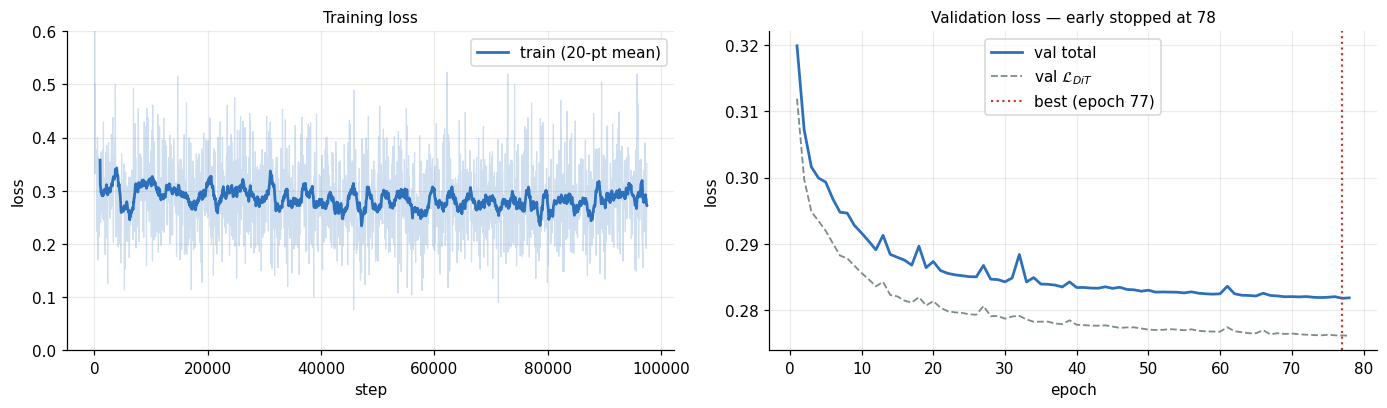

best validation total = 0.281793 at epoch 77; final epoch 78


In [5]:
step_re = re.compile(r"step=(\d+) loss=([\d.]+)")
val_re  = re.compile(r"validation epoch=(\d+) total=([\d.]+) dit=([\d.]+) smooth=([\d.]+)")
steps, losses, vep, vtot, vdit, vsm = [], [], [], [], [], []
for line in open("logs/phase1_wandb.log"):
    if (mt := step_re.search(line)) and "validation" not in line:
        steps.append(int(mt.group(1))); losses.append(float(mt.group(2)))
    if (mv := val_re.search(line)):
        vep.append(int(mv.group(1))); vtot.append(float(mv.group(2)))
        vdit.append(float(mv.group(3))); vsm.append(float(mv.group(4)))

best_i = int(np.argmin(vtot))
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6), constrained_layout=True)
k = 20
sm = np.convolve(losses, np.ones(k) / k, mode="valid")
axes[0].plot(steps, losses, color=BLUE, alpha=0.22, lw=.8)
axes[0].plot(steps[k-1:], sm, color=BLUE, lw=1.8, label=f"train ({k}-pt mean)")
axes[0].set_xlabel("step"); axes[0].set_ylabel("loss"); axes[0].set_ylim(0, 0.6)
axes[0].legend(); axes[0].set_title("Training loss", fontsize=10)

axes[1].plot(vep, vtot, color=BLUE, lw=1.8, label="val total")
axes[1].plot(vep, vdit, color=GREY, lw=1.2, ls="--", label=r"val $\mathcal{L}_{DiT}$")
axes[1].axvline(vep[best_i], color=RED, lw=1.4, ls=":",
                label=f"best (epoch {vep[best_i]})")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("loss")
axes[1].legend(); axes[1].set_title("Validation loss — early stopped at 78", fontsize=10)
plt.show()
print(f"best validation total = {min(vtot):.6f} at epoch {vep[best_i]}; "
      f"final epoch {vep[-1]}")

---
## 6. The first results — which looked good

With a trained backbone we can sample. Below, generated sequences beside real
ones. The evaluation reduces a sequence to detected peaks, links them greedily
into tracks, and scores the tracks — the same shape of pipeline a radar engineer
would use, with CFAR-style detection followed by association.

In [6]:
from src.train import build_model

ckpt = torch.load("checkpoints/phase1_wandb/best.pt", map_location=DEV)
cfg = ckpt["config"]
model = build_model(cfg, DEV); model.load_state_dict(ckpt["model"]); model.eval()
print(f"loaded best.pt — epoch {ckpt['epoch']}, step {ckpt['step']}, "
      f"{sum(p.numel() for p in model.parameters())/1e6:.2f} M params")

CACHE = "samples/nb_generated.pt"
if os.path.exists(CACHE):
    gen = torch.load(CACHE)
else:
    torch.manual_seed(1)
    gen = (diff.ddim_sample(model, (32, 16, 64, 64), DEV, steps=50).cpu()
           * stats["std"] + stats["mean"])
    torch.save(gen, CACHE)

real = []
for f in sorted(__import__("pathlib").Path("data/cache").glob("val_*.pt")):
    for it in torch.load(f):
        real.append(it["x"])
        if len(real) >= 64: break
    if len(real) >= 64: break
real = torch.stack(real)
print("generated", tuple(gen.shape), " real", tuple(real.shape))

loaded best.pt — epoch 63, step 78750, 9.83 M params


generated (32, 16, 64, 64)  real (64, 16, 64, 64)


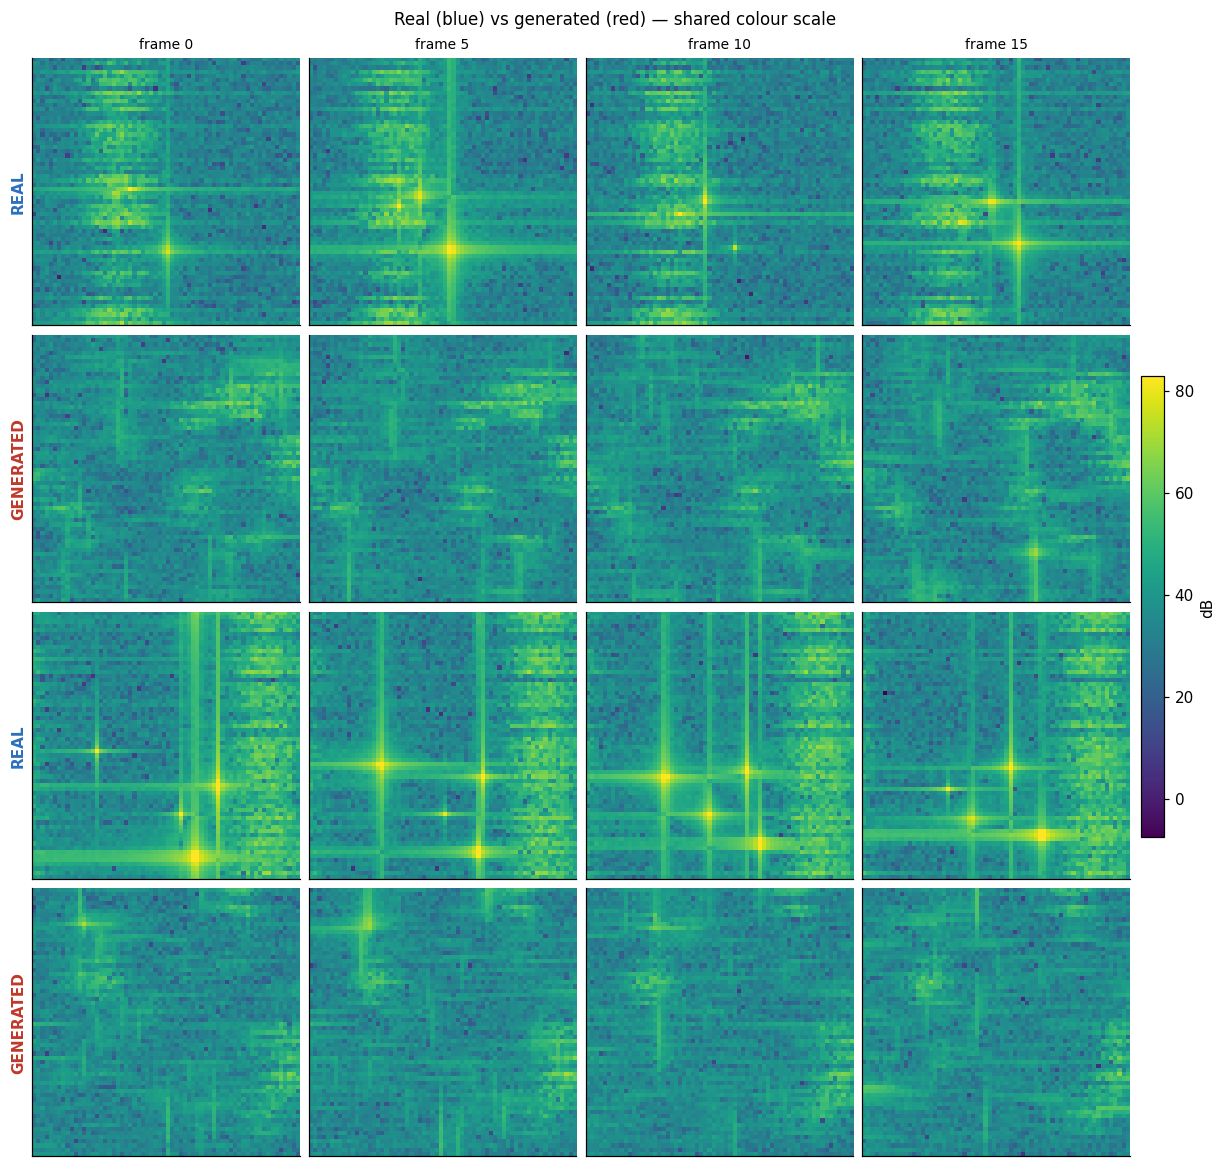

In [7]:
show = [0, 5, 10, 15]
rows = [(real[0], "REAL"), (gen[0], "GENERATED"),
        (real[3], "REAL"), (gen[5], "GENERATED")]
# ONE colour scale for every panel, so brightness is directly comparable.
allv = torch.cat([s[show].flatten() for s, _ in rows])
vmin, vmax = float(allv.min()), float(np.percentile(allv.numpy(), 99.95))

fig, axes = plt.subplots(4, len(show), figsize=(11, 10.5), constrained_layout=True)
for row, (src, lbl) in enumerate(rows):
    for col, l in enumerate(show):
        ax = axes[row, col]
        im = ax.imshow(src[l], origin="lower", cmap="viridis", vmin=vmin,
                       vmax=vmax, aspect="equal")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if row == 0: ax.set_title(f"frame {l}", fontsize=9)
        if col == 0:
            ax.set_ylabel(lbl, fontsize=10,
                          color=BLUE if lbl == "REAL" else RED, fontweight="bold")
cb = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.021, pad=0.01)
cb.set_label("dB")
fig.suptitle("Real (blue) vs generated (red) — shared colour scale", fontsize=11)
plt.show()

Structurally the generated frames are believable: a textured clutter background
carrying brighter returns that persist across frames, with range and Doppler
sidelobe-like ridges. Plotted on a **shared** colour scale, though, one thing is
already visible by eye — the real frames contain small, very bright point
returns, and the generated ones do not reach the same peak brightness. Hold that
thought; it is the subject of section 7.

The original scoring did not flag it. On the track-based kinematic metrics the
generated sequences looked **equal to or better than** real data:

| Metric (↓ better) | Real reference | Generated |
|---|---:|---:|
| velocity inconsistency | 3.040 | **2.241** |
| Doppler drift | 0.706 | **0.432** |
| track persistence (↑) | 0.075 | **0.077** |
| marginal intensity L1 | **0.065** | 0.436 |

Three of four metrics favoured the generated data. The read at the time was
"motion is learned, maybe even over-smooth; only the intensity statistics are
off."

**Both halves of that conclusion turned out to be wrong.** The rest of this
notebook is why.

---
## 7. Problem 1 — the intensity distribution

`marginal_l1` compares the histogram of all pixel values in generated data
against real data:

$$\mathrm{L1} = \sum_{b=1}^{64} \left| \frac{h^{\text{gen}}_b}{\sum_b h^{\text{gen}}_b} - \frac{h^{\text{real}}_b}{\sum_b h^{\text{real}}_b} \right| \;\in [0, 2]$$

It sat at **0.436**, against a real-vs-real floor of **0.065** — a factor of
about seven. Before concluding the model was at fault, the metric and the
protocol themselves had to be cleared. Five candidate explanations, each tested:

| Hypothesis | Test | Result |
|---|---|---|
| The DDIM $\hat{\mathbf{x}}_0$ clamp to $\pm 4\sigma$ truncates the range | fraction of generated mass at the boundary | $2.6\times10^{-5}$ — **rejected** |
| Outliers widen the shared histogram range | recompute over a robust percentile range | 0.4538 vs 0.4532 — **rejected** |
| The 0.065 floor used a different protocol | re-measure at the real protocol, 8 disjoint draws | floor = 0.052 — **rejected** |
| Too few DDIM steps | 50 / 100 / 250 steps, plus full ancestral DDPM | std 0.655 / 0.650 / 0.669 / 0.721 — **rejected** |
| Undertrained | compare epochs 10, 30, 50, 70 | std 0.659 → 0.667, flat — **rejected** |

The gap is real. What it looks like:

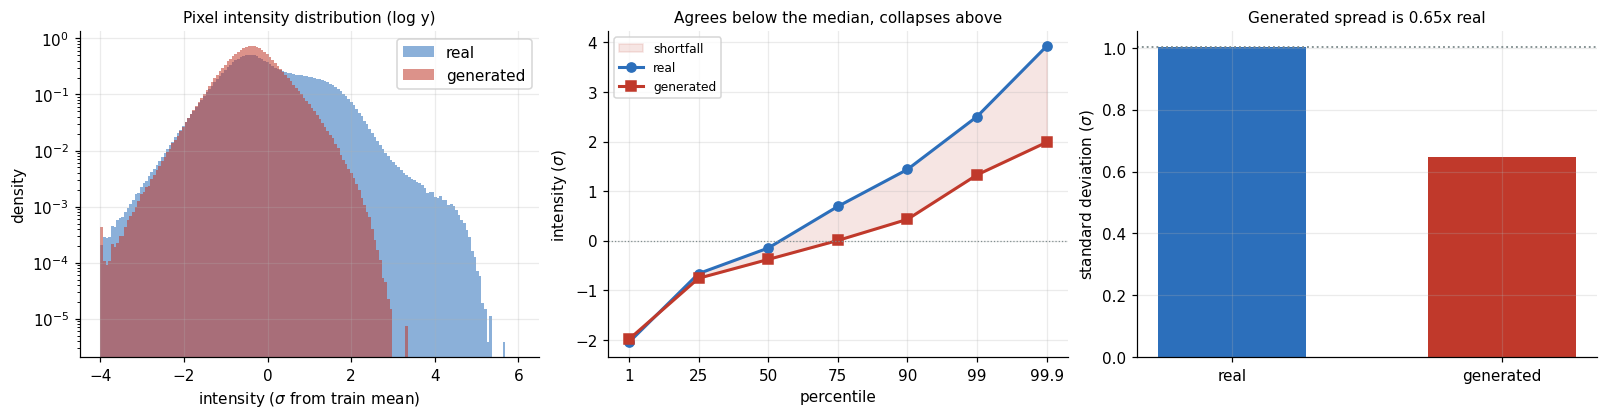

real  std 1.003   99.9th pct +3.92
gen   std 0.648   99.9th pct +1.99


In [8]:
D = json.load(open("samples/diag_marginal_l1.json"))
mean, std = D["norm_stats"]["mean"], D["norm_stats"]["std"]
rn = ((real - mean) / std).flatten()
gn = ((gen - mean) / std).flatten()

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.7), constrained_layout=True)

bins = np.linspace(-4, 6, 160)
axes[0].hist(rn.numpy(), bins=bins, density=True, color=BLUE, alpha=.55, label="real")
axes[0].hist(gn.numpy(), bins=bins, density=True, color=RED, alpha=.55, label="generated")
axes[0].set_yscale("log"); axes[0].legend()
axes[0].set_xlabel(r"intensity ($\sigma$ from train mean)"); axes[0].set_ylabel("density")
axes[0].set_title("Pixel intensity distribution (log y)", fontsize=10)

pcts = [1, 25, 50, 75, 90, 99, 99.9]
rq = np.percentile(rn.numpy(), pcts); gq = np.percentile(gn.numpy(), pcts)
xi = np.arange(len(pcts))
axes[1].fill_between(xi, gq, rq, color=RED, alpha=.13, label="shortfall")
axes[1].plot(xi, rq, "o-", color=BLUE, lw=2, ms=6, label="real")
axes[1].plot(xi, gq, "s-", color=RED, lw=2, ms=6, label="generated")
axes[1].axhline(0, color=GREY, lw=.8, ls=":")
axes[1].set_xticks(xi); axes[1].set_xticklabels([str(p) for p in pcts])
axes[1].set_xlabel("percentile"); axes[1].set_ylabel(r"intensity ($\sigma$)")
axes[1].legend(fontsize=8, loc="upper left")
axes[1].set_title("Agrees below the median, collapses above", fontsize=10)

axes[2].bar(["real", "generated"], [float(rn.std()), float(gn.std())],
            color=[BLUE, RED], width=.55)
axes[2].axhline(float(rn.std()), color=GREY, ls=":", lw=1.2)
axes[2].set_ylabel(r"standard deviation ($\sigma$)")
axes[2].set_title(f"Generated spread is {float(gn.std())/float(rn.std()):.2f}x real",
                  fontsize=10)
plt.show()

print(f"real  std {float(rn.std()):.3f}   99.9th pct {np.percentile(rn.numpy(),99.9):+.2f}")
print(f"gen   std {float(gn.std()):.3f}   99.9th pct {np.percentile(gn.numpy(),99.9):+.2f}")

The noise floor is reproduced well — the two distributions agree closely at the
1st and 25th percentiles. Everything above the median is compressed. The bright
end, **which is where targets live**, is missing: real data reaches $+3.9\sigma$
at the 99.9th percentile, generated data only $+1.8\sigma$.

In radar terms the model is generating something with roughly the right noise
floor and badly degraded target-to-clutter contrast.

---
## 8. Problem 2 — the metrics were scoring the wrong thing

That result sits awkwardly next to section 6, where the *kinematic* metrics said
generated data was better than real. If target contrast is destroyed, how can
target motion be excellent?

It cannot. The metrics were not measuring targets.

Detection used a threshold of $\mathrm{median} + 12$ dB and kept the 8 strongest
local maxima per frame. Because the sequences carry ground truth, we can simply
ask what fraction of the resulting tracks correspond to a real target.

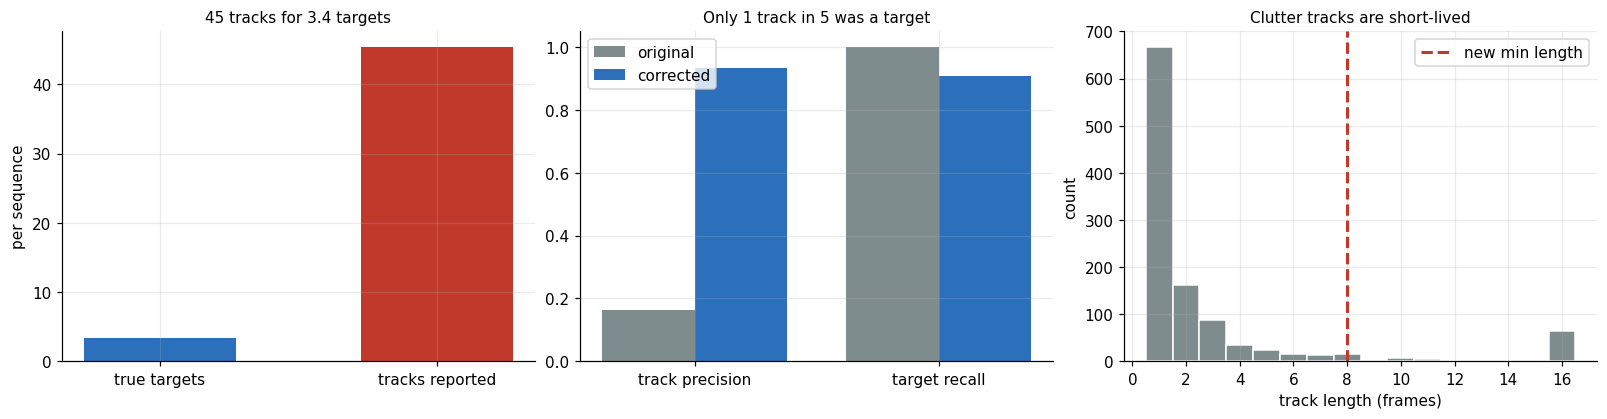

original : 16.2% precision, 46.1 tracks/seq
corrected: 93.5% precision, 3.1 tracks/seq vs 3.20 true targets


In [9]:
from src.eval.metrics import detect_peaks, link_tracks, filter_tracks

V = json.load(open("samples/diag_track_validity.json"))["real_detection_validity"]
R = json.load(open("samples/phase1_rescore.json"))

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.7), constrained_layout=True)

axes[0].bar(["true targets", "tracks reported"],
            [V["mean_true_targets_per_seq"], V["mean_tracks_per_seq"]],
            color=[BLUE, RED], width=.55)
axes[0].set_ylabel("per sequence")
axes[0].set_title(f"{V['mean_tracks_per_seq']:.0f} tracks for "
                  f"{V['mean_true_targets_per_seq']:.1f} targets", fontsize=10)

old = R["detector_validity"]["old_max_peaks8_no_filter"]
new = R["detector_validity"]["new_max_peaks5_min_len8"]
xi = np.arange(2); w = .38
axes[1].bar(xi - w/2, [old["track_precision"], old["target_recall"]], w,
            color=GREY, label="original")
axes[1].bar(xi + w/2, [new["track_precision"], new["target_recall"]], w,
            color=BLUE, label="corrected")
axes[1].set_xticks(xi); axes[1].set_xticklabels(["track precision", "target recall"])
axes[1].set_ylim(0, 1.05); axes[1].legend()
axes[1].set_title("Only 1 track in 5 was a target", fontsize=10)

lens = []
for it_x in real[:24]:
    lens += [len(t) for t in link_tracks([detect_peaks(f, max_peaks=8) for f in it_x])]
axes[2].hist(lens, bins=np.arange(1, 18) - .5, color=GREY, edgecolor="white")
axes[2].axvline(8, color=RED, lw=2, ls="--", label="new min length")
axes[2].set_xlabel("track length (frames)"); axes[2].set_ylabel("count")
axes[2].legend(); axes[2].set_title("Clutter tracks are short-lived", fontsize=10)
plt.show()

print(f"original : {old['track_precision']:.1%} precision, "
      f"{old['tracks_per_seq']:.1f} tracks/seq")
print(f"corrected: {new['track_precision']:.1%} precision, "
      f"{new['tracks_per_seq']:.1f} tracks/seq "
      f"vs {new['true_targets_per_seq']:.2f} true targets")

**Only 19.9% of reported tracks started on a real target.** The threshold is
relative to the frame median, so clutter fluctuations were detected freely, and
the metrics then averaged over all 45 tracks per sequence. Roughly four fifths of
every number in section 6 described clutter.

The fix needs no new physics. Real targets persist for the whole sequence;
clutter detections do not. Keeping the 5 strongest peaks and requiring a track to
span at least $L/2 = 8$ frames raises precision to **93.5%** at **90.7% recall**,
giving 3.11 tracks per sequence against 3.20 true targets.

### Re-scoring with corrected metrics

$\lambda$ unchanged, same checkpoint, same data — only the measurement changed:

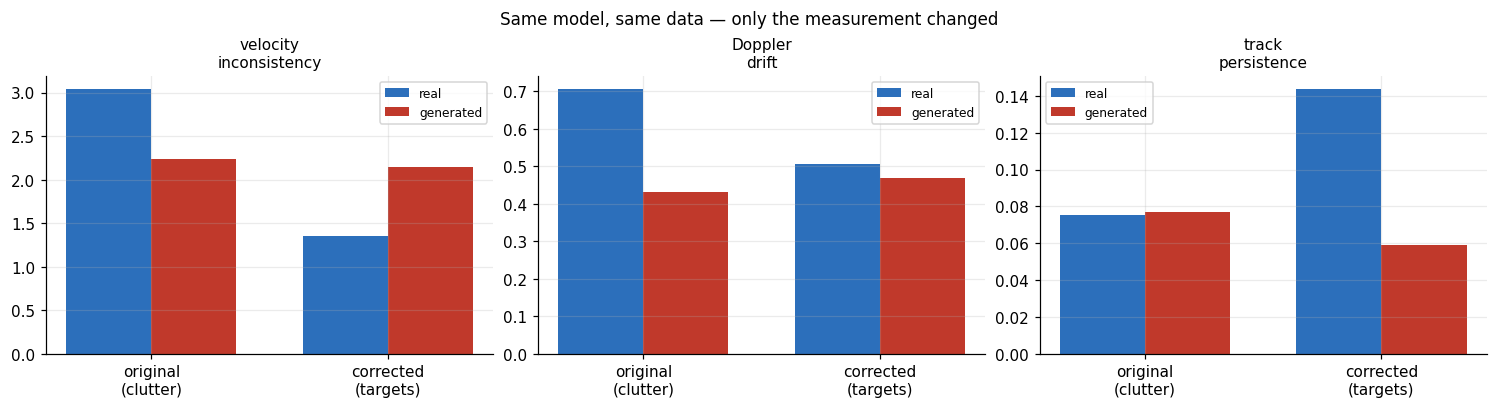

metric                    reference  generated
velocity_consistency          1.358      2.147
doppler_drift                 0.508      0.469
persistence                   0.144      0.059
target tracks/seq              3.09       2.59


In [10]:
ref, g = R["reference_real_vs_real"]["new"], R["generated"]["new"]
refo, go = R["reference_real_vs_real"]["old"], R["generated"]["old"]

keys = [("velocity_consistency", "velocity\ninconsistency"),
        ("doppler_drift", "Doppler\ndrift"),
        ("persistence", "track\npersistence")]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), constrained_layout=True)
for ax, (k, lbl) in zip(axes, keys):
    xi = np.arange(2); w = .36
    ax.bar(xi - w/2, [refo[k], ref[k]], w, color=BLUE, label="real")
    ax.bar(xi + w/2, [go[k], g[k]], w, color=RED, label="generated")
    ax.set_xticks(xi); ax.set_xticklabels(["original\n(clutter)", "corrected\n(targets)"])
    ax.set_title(lbl, fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Same model, same data — only the measurement changed", fontsize=11)
plt.show()

print(f"{'metric':<24}{'reference':>11}{'generated':>11}")
for k, _ in keys:
    print(f"{k:<24}{ref[k]:>11.3f}{g[k]:>11.3f}")
print(f"{'target tracks/seq':<24}{ref['n_target_tracks_per_seq']:>11.2f}"
      f"{g['n_target_tracks_per_seq']:>11.2f}")

**The conclusion inverts.** Where generated data appeared to beat real data on
velocity consistency (2.24 vs 3.04), measured on actual target tracks it is
**58% worse** (2.147 vs 1.358). Track persistence, which looked equal, is
**2.4× worse** (0.059 vs 0.144). The model also produces fewer target-like
tracks than real data (2.59 vs 3.09).

The one metric that survives is Doppler drift, where generated data remains
comparable to real.

A note on the exit criteria: Phase 1 does pass its written gate ("persistence
within 0.2 of reference"). But the reference value *is* 0.1437, so a tolerance of
0.2 admits any result between 0 and 0.34 — including a model that produces no
persistent tracks at all. That criterion cannot fail and should not be treated as
evidence.

---
## 9. Root cause

Two facts have to be reconciled. Training converged cleanly and the validation
loss is healthy — so the network learned *something*. Yet its samples have
degraded contrast and worse-than-real target motion.

The decisive experiment separates two abilities that are easy to conflate:

- **Restoration** — given a noisy version of a *real* sequence, recover it.
- **Synthesis** — given only noise, invent a plausible sequence.

Training only ever asks for the first. Sampling requires the second.

So: take real sequences, noise them to a known $t$, and inspect
$\hat{\mathbf{x}}_0$. If the tail is intact there, the network can represent
bright targets fine and the problem lies in generation.

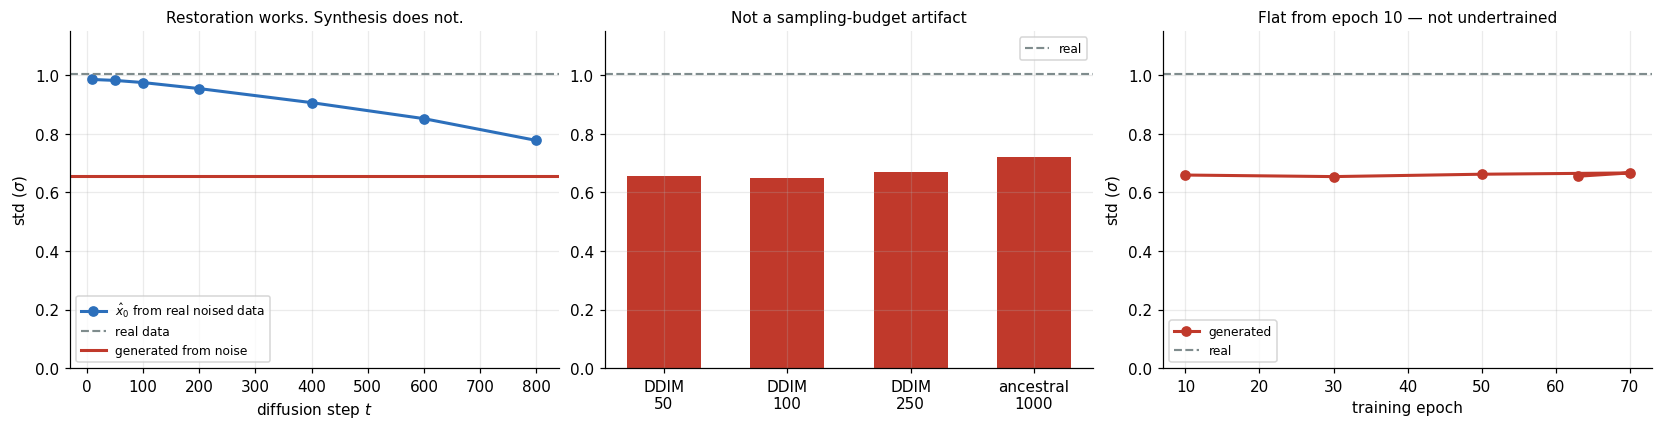

real std 1.003
  restore t=10   -> std 0.986
  restore t=100  -> std 0.975
  restore t=400  -> std 0.907
  restore t=800  -> std 0.777
  synthesize     -> std 0.655


In [11]:
T = json.load(open("samples/diag_tail_origin.json"))
A, Bs, Cp = T["A_denoise_fidelity"], T["B_sampler"], T["C_progression"]
real_std = T["real_normalized"]["std"]
tv = [int(k) for k in A if int(k) < 999]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), constrained_layout=True)

axes[0].plot(tv, [A[str(t)]["x0_hat"]["std"] for t in tv], "o-", color=BLUE,
             lw=2, label=r"$\hat{x}_0$ from real noised data")
axes[0].axhline(real_std, color=GREY, ls="--", lw=1.4, label="real data")
axes[0].axhline(Bs["ddim_50"]["stats"]["std"], color=RED, ls="-", lw=2,
                label="generated from noise")
axes[0].set_xlabel("diffusion step $t$"); axes[0].set_ylabel(r"std ($\sigma$)")
axes[0].set_ylim(0, 1.15); axes[0].legend(fontsize=8)
axes[0].set_title("Restoration works. Synthesis does not.", fontsize=10)

names = ["ddim_50", "ddim_100", "ddim_250", "ancestral_1000"]
axes[1].bar(range(4), [Bs[n]["stats"]["std"] for n in names], color=RED, width=.6)
axes[1].axhline(real_std, color=GREY, ls="--", lw=1.4, label="real")
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(["DDIM\n50", "DDIM\n100", "DDIM\n250", "ancestral\n1000"])
axes[1].set_ylim(0, 1.15); axes[1].legend(fontsize=8)
axes[1].set_title("Not a sampling-budget artifact", fontsize=10)

eps = [Cp[k]["epoch"] for k in Cp]; sds = [Cp[k]["stats"]["std"] for k in Cp]
axes[2].plot(eps, sds, "o-", color=RED, lw=2, label="generated")
axes[2].axhline(real_std, color=GREY, ls="--", lw=1.4, label="real")
axes[2].set_xlabel("training epoch"); axes[2].set_ylabel(r"std ($\sigma$)")
axes[2].set_ylim(0, 1.15); axes[2].legend(fontsize=8)
axes[2].set_title("Flat from epoch 10 — not undertrained", fontsize=10)
plt.show()

print(f"real std {real_std:.3f}")
for t in [10, 100, 400, 800]:
    print(f"  restore t={t:<4} -> std {A[str(t)]['x0_hat']['std']:.3f}")
print(f"  synthesize     -> std {Bs['ddim_50']['stats']['std']:.3f}")

The left panel is the result. Handed a real sequence buried in noise, the network
returns something with **std 0.986 against the real 1.003** — essentially perfect,
including the bright tail. Handed only noise, the same weights produce **0.655**.

The middle and right panels close the remaining escapes: more sampling steps do
not help, and the behaviour is identical from epoch 10 to epoch 70. This is not
an optimisation problem and not a sampling problem.

### Why — back to section 4

Recall that attention is temporal only: each of the 225 patch sites is an
independent sequence model, blind to every other site.

During restoration this costs nothing. The noisy input *already contains* the
target — in the right place, at roughly the right brightness — so each site only
has to sharpen what it can already see. Spatial structure arrives for free in the
input.

During synthesis the input is white noise, which says nothing about where targets
belong. A site must decide its own brightness alone, and no site can agree with
any other that *this* location is the target and the rest are background. Under a
squared-error objective the best any isolated site can do is hedge toward the
conditional mean. Nothing commits to being bright, and the distribution collapses
toward the mode — dropping the variance and, because the intensity distribution
is right-skewed, the mean along with it.

That prediction is directly testable in the imagery: the model should still make
*some* bright specks, but it should be unable to assemble them into the large
coherent structures real RD maps contain.

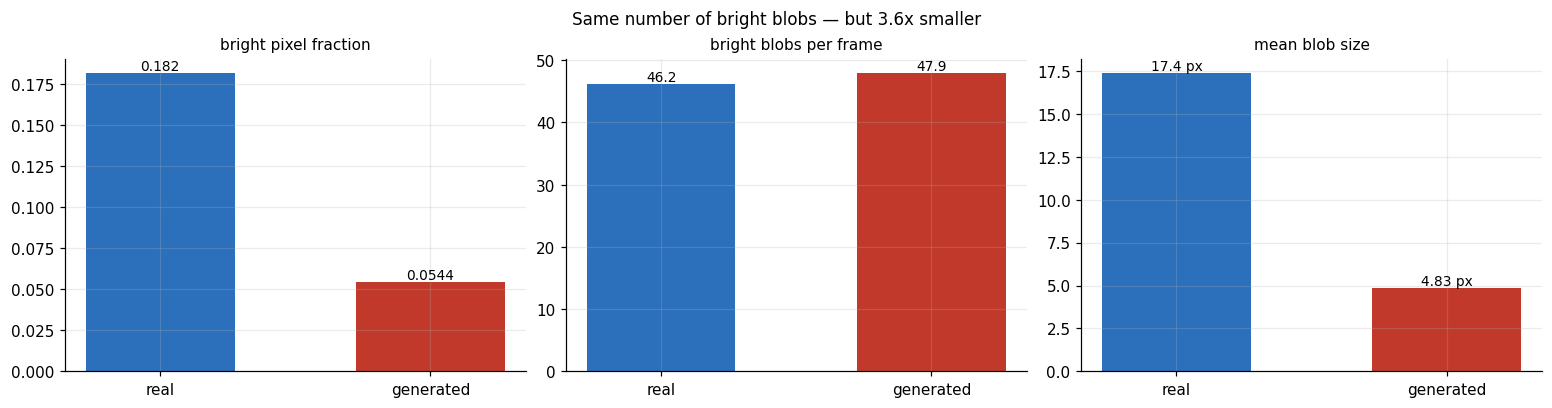

In [12]:
S = json.load(open("samples/diag_track_validity.json"))["bright_structure"]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)
for ax, key, ttl, unit in [
        (axes[0], "bright_frac", "bright pixel fraction", ""),
        (axes[1], "blobs_per_frame", "bright blobs per frame", ""),
        (axes[2], "mean_blob_px", "mean blob size", " px")]:
    ax.bar(["real", "generated"], [S["real"][key], S["generated"][key]],
           color=[BLUE, RED], width=.55)
    ax.set_title(ttl, fontsize=10)
    for i, v in enumerate([S["real"][key], S["generated"][key]]):
        ax.text(i, v, f"{v:.3g}{unit}", ha="center", va="bottom", fontsize=9)
fig.suptitle("Same number of bright blobs — but 3.6x smaller", fontsize=11)
plt.show()

Confirmed. The model emits **the same number** of bright blobs as real data
(47.9 vs 46.2 per frame) but each is **3.6× smaller** (4.8 px vs 17.4 px), and
only a third as many pixels are bright overall. It scatters isolated specks
instead of forming extended structures — precisely what independent per-site
decisions produce.

> ### The finding
>
> Temporal-only attention is **sufficient for restoration and temporal
> coherence**, and **insufficient for unconditional spatial synthesis**. The
> network can sharpen structure it is shown but cannot invent structure it is
> not. This is a property of the architecture, not of the training run.

---
## 10. Where this leaves the project

**Built and verified.** Temporal simulator with ground truth, 22 000-sequence
cached dataset, DDPM/DDIM machinery, the temporal DiT, a training harness with
validation and resumable checkpointing, physics and CFAR evaluation, and all
three phases implemented — 55 passing tests, everything reproducible from the
repository.

**Established.**

1. The intensity gap is architectural, not a training or sampling defect. The
   evidence rules out five alternatives and the mechanism is visible in code.
2. The earlier positive result was a measurement artifact. Corrected, the
   backbone is worse than real data on every target-level kinematic metric.
3. Phase 2's exit criteria could not have gated anything, since they were defined
   on the clutter-dominated numbers. The metric fix is a prerequisite for the
   remaining phases regardless of what is decided below.

**The open decision.** Note that the design spec already lists factorised
spatial-temporal attention under *"out of scope — possible later ablation"*, so
this lands on a question the proposal deliberately deferred rather than
contradicting it.

| Option | What it means | Cost |
|---|---|---|
| **A. Test spatial attention** | Add factorised spatial + temporal blocks, train a short controlled comparison against the current backbone. Confirms or refutes the diagnosis directly. | ~1 day |
| **B. Reframe around restoration** | Keep temporal-only attention and pivot to the regime where it demonstrably works — denoising, super-resolution, conditional infill on measured data. The near-perfect restoration result becomes the headline. | no retraining |
| **C. Proceed to Phases 2–3 as planned** | Physics losses and conditioning may partially compensate. Note that conditioning as implemented is a single global vector added to the timestep embedding, carrying no spatial layout — so it cannot by itself tell a site to be a target. | ~1 day each |

Options A and B are not exclusive: A is the ablation the spec anticipated, B is
the framing if the ablation shows the constraint is fundamental.

### Questions for discussion

1. Is the restoration/synthesis distinction the right way to frame the
   contribution, or should unconditional synthesis remain the target?
2. If we add spatial attention, how much of the proposal's efficiency argument
   survives, and does the comparison stay honest at matched parameter count?
3. Is a negative result on temporal-only synthesis publishable on its own, given
   it is a clean, well-isolated finding?

---

*Reproduce everything here with `scripts/diag_marginal_l1.py`,
`scripts/diag_tail_origin.py`, `scripts/diag_track_validity.py` and
`scripts/rescore_phase1.py`. Full write-up in
`docs/notes/2026-08-07-phase1-marginal-l1-diagnosis.md`.*